# Monte Carlo uncertainty analysis

In [23]:
import openturns as ot
import matplotlib.pyplot as plt
import os
import pickle
import numpy as np
import rasterio
from rasterio.enums import Resampling, Compression
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.vrt import WarpedVRT
from rasterio.windows import from_bounds
import tifffile as tf
import yaml
import utm
from osgeo import gdal
import dask.array as da

In [27]:
base_dir = r'P:\11210268-014-flood-and-health\FloodsAndHealthTool-main'
em_dir = os.path.join(base_dir, 'output','sensitivity_analysis','emissionsRasters')
sa_dir = os.path.join(base_dir, 'output','sensitivity_analysis')
maps_dirpre = os.path.join(base_dir, 'output', 'preprocessing')
scen_dir = os.path.join(base_dir, 'tool', 'default_ymls')

flood_path = os.path.join(maps_dirpre, 'flooded_zoom_new.tif')
demographic_path = os.path.join(maps_dirpre, 'clipped_population.tif')
emissions_path = os.path.join(maps_dirpre, 'ecoli_emissions_cropped.tif')

Define supplementary functions

In [25]:
def load_tiff(file_path, dtype=np.float32):
    """Loads a TIFF file and handles NoData values."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    with tf.TiffFile(file_path) as tif:
        data = tif.asarray().astype(dtype)
        no_data_value = tif.pages[0].tags.get('GDAL_NODATA', None)

        if no_data_value:
            try:
                no_data_value = float(no_data_value.value)
                data[data == no_data_value] = np.nan  # Set NoData to NaN
            except ValueError:
                pass  # Ignore if conversion fails

    return data

def load_multiband_tiff(file_path):
    """Loads a multi-band TIFF file (e.g., population density)."""
    dataset = gdal.Open(file_path)
    if dataset is None:
        raise RuntimeError(f"Failed to open dataset: {file_path}")

    bands = dataset.RasterCount  # Get number of bands
    return np.array([dataset.GetRasterBand(i + 1).ReadAsArray().astype(np.float32) for i in range(bands)])

def get_utm_zone(source_path):
    """Get most appropriate UTM zone for area in question"""
    with rasterio.open(source_path) as src:
        bounds = src.bounds
    
    # Calculate the center latitude and longitude of the raster
    center_lon = (bounds.left + bounds.right) / 2
    center_lat = (bounds.top + bounds.bottom) / 2
    
    # Get UTM zone information from lat/lon
    utm_zone = utm.from_latlon(center_lat, center_lon)
    
    # Extract zone number and hemisphere
    zone_number = utm_zone[2]
    hemisphere = utm_zone[3]
    
    # If the latitude is negative, it's in the southern hemisphere
    if center_lat < 0:
        hemisphere = 'S'
    
    # Determine the EPSG code based on hemisphere and zone number
    if hemisphere == 'S':
        epsg_code = 32700 + zone_number  # Southern Hemisphere
    else:
        epsg_code = 32600 + zone_number  # Northern Hemisphere

    return epsg_code### Define supplementary functions

def get_cell_area(source_path):
    """"Get area of gridcell in m2."""
    with rasterio.open(source_path) as src:
        # Transform the raster to a CRS with units in meters
        dst_crs = get_utm_zone(source_path)
        transform, width, height = rasterio.warp.calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)

        # Create an empty array to store reprojected data (not saving to disk)
        reprojected_data = np.empty((height, width), dtype=src.dtypes[0])
        
        # Reproject the raster data into the new CRS
        reproject(
            source=rasterio.band(src, 1),
            destination=reprojected_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
        )
        
        # Cell dimensions in meters
        cell_width = transform[0]  # X resolution
        cell_height = -transform[4]  # Y resolution (negative because Y decreases in raster)
        
        # Area of a single cell
        cell_area = cell_width * cell_height
        return cell_area

### Define distributions
Alpha and beta: use beta distribution. Prioritise values used previously in waterborne studies.

Waterborne alpha and beta different to foodborne:  https://doi.org/10.1046/j.1365-2672.2001.01421.x (search for 'matrix')

In [30]:
# Define Beta distributions (custom range)
alpha_distribution = ot.Beta(2, 5, 0.001, 0.4)
beta_distribution = ot.Beta(2, 8, 0.5, 180)

# Define Uniform distributions
ecoli_distribution = ot.Uniform(1e7, 1e10)  # E.coli concentrations
flood_distribution = ot.Uniform(0.5, 1.5)  # Flood depth
ingestion_distribution = ot.Uniform(0.5, 1.5)  #Ingestion

# Create a list of distributions
distributions = [ecoli_distribution, flood_distribution, ingestion_distribution, alpha_distribution, beta_distribution]

# Create a joint distribution
joint_distribution = ot.ComposedDistribution(distributions)

Generate samples

In [31]:
# Generate samples (10,000 samples in this example)
n_samples = 10000
sample = joint_distribution.getSample(n_samples)

# Convert to a NumPy array for easier processing
import numpy as np
sample_array = np.array(sample)

For sensitivity analysis we generated emissions rasters. Took a long time and would like to reuse them rather than making more.

For each sampled ecoli value, check which pre-existing emissions raster is closest and use that (there are 1536 of them).

In [33]:
# load param_values used in SA
with open(os.path.join(sa_dir, 'param_values.pkl'), 'rb') as f:
    param_values = pickle.load(f)

# Get the emissions values
emVals = [x[0] for x in param_values]

#Get list of raster files
raster_files = os.listdir(em_dir)

# Find the closest raster file for each new emissions value
emRasters = []
for target_value in [x[0] for x in sample_array]:
    closest_index = min(range(len(emVals)), key=lambda i: abs(emVals[i] - target_value))
    closest_raster_file = raster_files[closest_index]
    emRasters.append(closest_raster_file)

Model setup

In [34]:
# get area of gridcell in m2
cell_area = get_cell_area(flood_path)

# Load single-band flood data
flood = load_tiff(flood_path)
# If there are positive values, make these negative
flood[flood>0] = -flood[flood>0]

# Load multi-band population data (Children, Adults, Population Density)
children, adults, popdens = load_multiband_tiff(demographic_path)

# Read exposure data from YAML file
with open(os.path.join(scen_dir,"Ingestion_scenarios.yml"), "r") as file:
    exposure_data = yaml.safe_load(file)

Define model function

In [42]:
def run_model(i, params):
    """Runs the model, based on prescribed inputs"""
    emissionsRaster = os.path.join(em_dir, emRasters[i])
    emissions = load_tiff(emissionsRaster)

    # Calculate E.coli concentration/100ml
    EcoliConc = emissions/(cell_area * (-1) * flood * params[1] *10000)

    # Adjust flood data and create classes for the flooded area ###
    wclass = flood * params[1]                               # create a copy of the flood map
    wclass[wclass>0]=np.nan                                  # filter the dry land out        
    wclass[np.logical_and(wclass<0,wclass>=-0.1)]= 1         # assign the classes
    wclass[np.logical_and(wclass<-0.1,wclass>=-0.5)]=2                                  
    wclass[np.logical_and(wclass<-0.5,wclass>=-1.5)]=3
    wclass[wclass<-1.5]= 4
    
    # Process exposure data
    exposure_data2 = {}
    event_in_hours = 1 #e.g. 1 if event lasts 1 hour; 0.25 if event lasts 15 mins
    for scenario, details in exposure_data.items():
        quantity, unit = details["ing"], details["unit"]
        quantity = quantity * params[2]
        if unit == "ml/event":
            unit = "ml/h"
            quantity = quantity / event_in_hours
        exposure_data2[scenario] = {"ing": quantity, "unit": unit}

    #Calculate adult dose
    dose_ad = wclass.copy()
    dose_ad[dose_ad==1]=np.nan
    dose_ad[np.logical_or(dose_ad==2,dose_ad==3)] = exposure_data2["Wading_Adult"]["ing"]*EcoliConc[np.logical_or(dose_ad==2,dose_ad==3)]/100 #Divide by 100 because E.Coli is per 100ml
    dose_ad[dose_ad==4] = exposure_data2["Swimming_Adult"]["ing"]*EcoliConc[dose_ad==4]/100
    
    # Calculate child dose
    dose_ch = wclass.copy()
    dose_ch[dose_ch==1]=np.nan
    dose_ch[dose_ch==2] = exposure_data2["Wading_Children"]["ing"]*EcoliConc[dose_ch==2]/100
    dose_ch[np.logical_or(dose_ch==3,dose_ch==4)] = exposure_data2["Swimming_Children"]["ing"]*EcoliConc[np.logical_or(dose_ch==3,dose_ch==4)]/100

    # Retrieve pathogen-specific parameters
    alpha = params[3]
    beta = params[4]
    
    # Calculate infection risk
    InfRisk_Ad = 1 - (1+(dose_ad/beta))**-alpha
    InfRisk_Ch = 1 - (1+(dose_ch/beta))**-alpha

    # Calculate number of infections
    Inf_ad = InfRisk_Ad * adults
    Inf_ch = InfRisk_Ch * children
    totAd = int(round(np.nansum(Inf_ad),0))
    totCh = int(round(np.nansum(Inf_ch),0))

    return totAd, totCh

Run model

In [43]:
# Run the model for each sample and collect outputs
outputs = []
for i, params in enumerate(sample_array):
    output = run_model(i, params)
    outputs.append(output)


Analyse results

In [49]:
outputs = np.array(outputs)
output_ad = outputs[:, 0]  # First output
output_ch = outputs[:, 1]  # Second output

print(f"Median: {np.median(output_ad)}")
print(f"Mean: {np.mean(output_ad)}")
print(f"5th Percentile: {np.percentile(output_ad, 5)}")
print(f"25th Percentile: {np.percentile(output_ad, 25)}")
print(f"75th Percentile: {np.percentile(output_ad, 75)}")
print(f"95th Percentile: {np.percentile(output_ad, 95)}")


Median: 14815.5
Mean: 16567.0867
5th Percentile: 2778.6000000000004
25th Percentile: 8351.25
75th Percentile: 23022.0
95th Percentile: 36665.84999999999


Plot output distribution

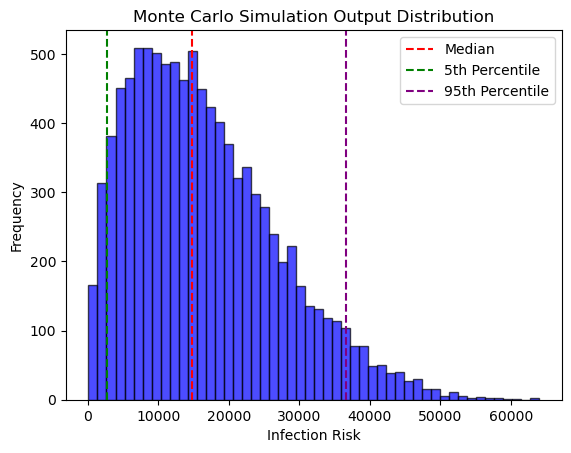

In [47]:
plt.hist(output_ad, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(np.median(output_ad), color='red', linestyle='--', label='Median')
plt.axvline(np.percentile(output_ad, 5), color='green', linestyle='--', label='5th Percentile')
plt.axvline(np.percentile(output_ad, 95), color='purple', linestyle='--', label='95th Percentile')
plt.title('Monte Carlo Simulation Output Distribution')
plt.xlabel('Infection Risk')
plt.ylabel('Frequency')
plt.legend()
plt.show()